In [1]:
%%time
%matplotlib inline
import rioxarray
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, make_scorer, mean_absolute_error
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import GradientBoostingRegressor
import importlib 
import matplotlib.pyplot as plt

CPU times: total: 1.66 s
Wall time: 2.63 s


In [2]:
vv = rioxarray.open_rasterio('../input/STVV_202223.tif')
vh = rioxarray.open_rasterio('../input/STVH_202223.tif')
ndvi = rioxarray.open_rasterio('../input/STNDVI_202223.tif')

# ndvi = rioxarray.open_rasterio('../input/cut_files/ndvi_cut_ex.tif')
# vh = rioxarray.open_rasterio('../input/cut_files/vh_cut_ex.tif')


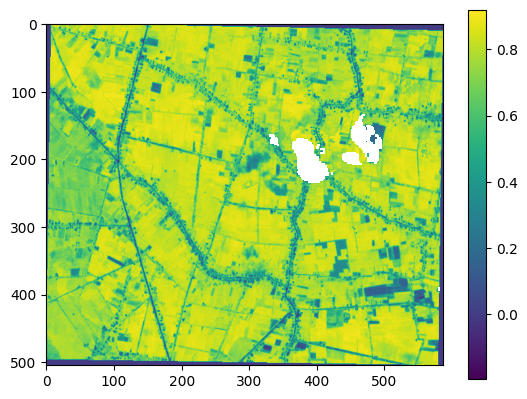

In [4]:
plt.imshow(ndvi[5], cmap='viridis')  # Display Band 10
plt.colorbar()  # Show the scale
plt.show()

In [4]:
ndvi

<xarray.DataArray (band: 13, y: 8874, x: 9902)> Size: 5GB
[1142314524 values with dtype=float32]
Coordinates:
  * band         (band) int64 104B 1 2 3 4 5 6 7 8 9 10 11 12 13
  * x            (x) float64 79kB 5.548e+05 5.548e+05 ... 6.538e+05 6.538e+05
  * y            (y) float64 71kB 1.106e+06 1.106e+06 ... 1.017e+06 1.017e+06
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0
    long_name:      NDVI

In [3]:
import geopandas as gpd
# train_path = "../input/STtrain1130v2.shp"  
train_path =  "../input/ST_training_data_updated/ST_training_data_updated.shp"  
ground_points = gpd.read_file(train_path)
ground_points.shape

(467, 7)

In [4]:
ground_points

,No,X,Y,LU2022,Hientrang,HT_code,geometry
0,1.0,603860.819,1081162.862,Pomelo,CLN,5,POINT (603860.819 1081162.862)
1,2.0,601306.410,1082782.940,Pomelo,CLN,5,POINT (601306.41 1082782.94)
2,3.0,601084.510,1081351.870,Pomelo,CLN,5,POINT (601084.51 1081351.87)
3,4.0,602193.760,1079205.220,Pomelo,CLN,5,POINT (602193.76 1079205.22)
4,5.0,602459.000,1080946.000,Pomelo,CLN,5,POINT (602459 1080946)
...,...,...,...,...,...,...,...
462,NaN,NaN,NaN,None,TS,6,POINT (600656.321 1038139.632)
463,NaN,NaN,NaN,None,TS,6,POINT (600583.222 1038161.094)
464,NaN,NaN,NaN,None,TS,6,POINT (600674.357 1038000.009)
465,NaN,NaN,NaN,None,TS,6,POINT (600704.512 1037956.781)


In [5]:
def extract_data_with_HTcode(ground_points, average_ndvi, dsvh, dsvv):
    datasets = {}
    for idx, point in ground_points.iterrows():
        
        # Ensure each HT_code has its own dictionary
        if point.HT_code not in datasets:
            datasets[point.HT_code] = {'ndvi': [], 'vh': [], 'vv': []}
        # Get the data for this point
        ndvi_data = average_ndvi.sel(x=point.geometry.x, y=point.geometry.y, method='nearest').values
        vh_data = dsvh.sel(x=point.geometry.x, y=point.geometry.y, method='nearest').values
        vv_data = dsvv.sel(x=point.geometry.x, y=point.geometry.y, method='nearest').values
        
        # Append the data to the lists for this HT_code
        datasets[point.HT_code]['ndvi'].append(ndvi_data)
        datasets[point.HT_code]['vh'].append(vh_data)
        datasets[point.HT_code]['vv'].append(vv_data)
    
    return datasets

In [6]:
full_data = extract_data_with_HTcode(ground_points, ndvi, vh, vv)

In [7]:
ht_code = 1
lua2_ndvi = full_data[ht_code]['ndvi']
lua2_vh = full_data[ht_code]['vh']
lua2_ndvi

[array([        nan,         nan,         nan,  0.7838173 ,  0.2594822 ,
                nan,         nan, -0.01014197,         nan,         nan,
                nan,  0.04412892,         nan], dtype=float32),
 array([        nan,  0.05541343,         nan,         nan,  0.04872111,
        -0.03975514, -0.02526664,  0.06633194, -0.03085015,         nan,
                nan,         nan,         nan], dtype=float32),
 array([        nan,  0.03639242,         nan, -0.02970295,         nan,
         0.21961932,  0.1123914 ,  0.00693567,  0.02815771,         nan,
                nan, -0.02027068,  0.07577639], dtype=float32),
 array([       nan, 0.19116719,        nan, 0.63182616, 0.25624552,
        0.22557077, 0.21399492, 0.2436642 , 0.12472966,        nan,
               nan,        nan, 0.30766046], dtype=float32),
 array([0.03151124,        nan,        nan,        nan,        nan,
               nan, 0.14684573, 0.1211228 ,        nan,        nan,
               nan,        nan, 0.104

In [32]:
len(lua2_vh)
# lua2_vh[0].shape[0]

55

In [8]:
import importlib
import fourierParam as params
# Reload module
importlib.reload(params)
months = np.arange(13)
scales = params.lua2v_scale 
bias = params.lua2v_bias
bias

0.6699999999998791

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft, fftfreq
# bias =  0.6699999999998791
# scale_factor = 0.15279367314245765
# Tạo mảng lưu NDVI nội suy
ndvi_preds = []
for i, vh in enumerate(lua2_vh):
    
    fft_vh = fft(vh)
    intercep = fft_vh*scales
    res = np.real(ifft(intercep)) + bias
    ndvi_preds.append(res)

In [10]:
ndvi_preds

[array([0.06547431, 0.22041025, 0.62975314, 0.7145639 , 0.66074488,
        0.27192338, 0.23477725, 0.27591176, 0.24804854, 0.0994553 ,
        0.15755427, 0.30584293, 0.06818586]),
 array([0.21250321, 0.36845755, 0.36306122, 0.30698099, 0.33649049,
        0.36495949, 0.32105144, 0.18309215, 0.07582123, 0.25186018,
        0.55642832, 0.46813894, 0.40458931]),
 array([0.42509771, 0.30110428, 0.31362585, 0.2714449 , 0.38677845,
        0.46903698, 0.44528524, 0.36345202, 0.28961771, 0.28688631,
        0.27758586, 0.31489227, 0.49055842]),
 array([0.29758251, 0.35146841, 0.46110021, 0.48072854, 0.49289713,
        0.45028514, 0.31175687, 0.15196727, 0.15460312, 0.07746903,
        0.40118603, 0.43545595, 0.20072107]),
 array([0.40220478, 0.19545737, 0.17920895, 0.42015128, 0.46252331,
        0.17368535, 0.27970284, 0.42327603, 0.58494086, 0.46017873,
        0.31928816, 0.3635182 , 0.52865269]),
 array([0.46382617, 0.40265184, 0.37658791, 0.46031667, 0.40709604,
        0.46316233, 0.

In [26]:
# def normalize_to_minus1_1(array):
#     min_val = np.min(array)
#     max_val = np.max(array)
#     if max_val == min_val:  # Tránh chia cho 0
#         return np.zeros_like(array)
#     normalized = -1 + 2 * (array - min_val) / (max_val - min_val)
#     return normalized

# # Áp dụng chuẩn hóa cho từng mảng
# normalized_data = normalize_to_minus1_1(ndvi_preds)

# # In kết quả
# print(normalized_data)

In [11]:
import matplotlib.pyplot as plt
import numpy as np

import matplotlib.pyplot as plt

def draw_ndvi(actual_values, predicted_values, name):
    for i, data in enumerate(actual_values):
        plt.plot(months, data, marker='o', linestyle='-', color='blue', markersize=4, linewidth=0.75, label='Actual Values (o)' if i == 0 else "")
    for i, data in enumerate(predicted_values):
        plt.plot(months, data, marker='x', linestyle='--', color='red', markersize=4, linewidth=0.75, label='predicted Values (o)' if i == 0 else "")
    plt.xlabel('Months')
    plt.ylabel('NDVI values')
    plt.title(f'Comparison: Actual vs Predicted Values in {name} code over 13 months')
    # Adding grid
    plt.grid(True)
    plt.legend(loc='best')
    # Adding legend to differentiate the lines
    plt.legend()
    # Adjusting the limits of the axes
    # plt.xlim(0, max(len(arr) for arr in actual_values))  # Adjust x-axis limits based on the longest array
    # plt.ylim(-1, 1)  # Example: Setting y-axis limits
    # Display the plot
    plt.show()

    


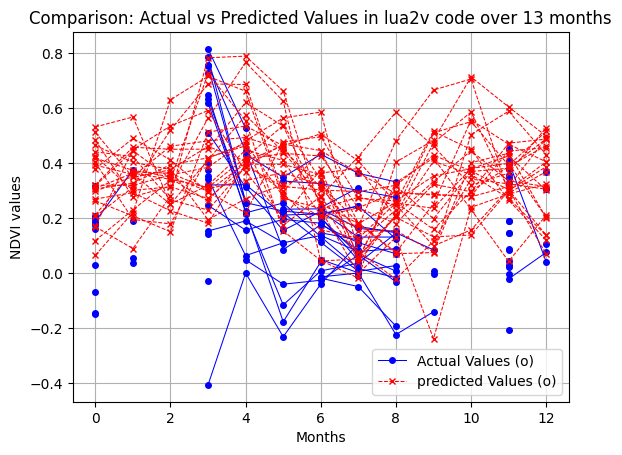

In [12]:
draw_ndvi(lua2_ndvi, ndvi_preds, "lua2v")


In [101]:
import numpy as np
alpha = 0.3
def custom_clip_ndvi(ndvi_list):
    ndvi_clipped = []
    for ndvi in ndvi_list:
        ndvi_corrected = ndvi.copy()
        print(f"before: {ndvi_corrected}")
        # Giá trị vượt trên 1 → log nén
        mask_high = ndvi_corrected > 1
        ndvi_corrected[mask_high] = 1 + alpha * np.log10(ndvi_corrected[mask_high] - 1 + 1e-6)
        print(f"after 1: {ndvi_corrected}")
        # Giá trị nhỏ hơn -1 → log nén đối xứng
        mask_low = ndvi_corrected < -1
        ndvi_corrected[mask_low] = -1 - alpha * np.log10(-ndvi_corrected[mask_low] - 1 + 1e-6)
        print(f"after 2: {ndvi_corrected}")
        ndvi_clipped.append(ndvi_corrected)
    
    return ndvi_clipped



In [37]:
def normalize(data):
    data_min = np.nanmin(data)
    data_max = np.nanmax(data)
    
    # Áp dụng công thức chuẩn hóa
    normalized = 2 * (data - data_min) / (data_max - data_min) - 1
    
    # Giữ nguyên giá trị NaN
    normalized = np.where(np.isnan(data), np.nan, normalized)
    return normalized

In [ ]:
# alpha = 0.3
# def custom_clip_ndvi_array(ndvi_array):
#     ndvi_corrected = ndvi_array.copy()
#     mask_high = ndvi_corrected > 1
#     mask_low = ndvi_corrected < -1
    
#     ndvi_corrected[mask_high] = 1 + alpha + np.log10(ndvi_corrected[mask_high] - 1 + 1e-6)
#     ndvi_corrected[mask_low] = -1 - alpha + np.log10(-ndvi_corrected[mask_low] - 1 + 1e-6)
    
#     return ndvi_corrected


In [112]:
nor = custom_clip_ndvi(ndvi_preds)


before: [ 0.79689862  0.56287414  0.04291373 -0.00745007  0.39644357  0.55711302
  0.60318317  0.58662769  0.11728748  0.02455208  0.40907369  0.56102214
  0.56742356]
after 1: [ 0.79689862  0.56287414  0.04291373 -0.00745007  0.39644357  0.55711302
  0.60318317  0.58662769  0.11728748  0.02455208  0.40907369  0.56102214
  0.56742356]
after 2: [ 0.79689862  0.56287414  0.04291373 -0.00745007  0.39644357  0.55711302
  0.60318317  0.58662769  0.11728748  0.02455208  0.40907369  0.56102214
  0.56742356]
before: [ 0.36374155 -0.03969004  0.24362929  0.67134753  0.26873961  0.58170415
  0.344374    0.1643196   0.27621675  0.6990415   0.35437527  0.62752556
  0.54376298]
after 1: [ 0.36374155 -0.03969004  0.24362929  0.67134753  0.26873961  0.58170415
  0.344374    0.1643196   0.27621675  0.6990415   0.35437527  0.62752556
  0.54376298]
after 2: [ 0.36374155 -0.03969004  0.24362929  0.67134753  0.26873961  0.58170415
  0.344374    0.1643196   0.27621675  0.6990415   0.35437527  0.62752556
  

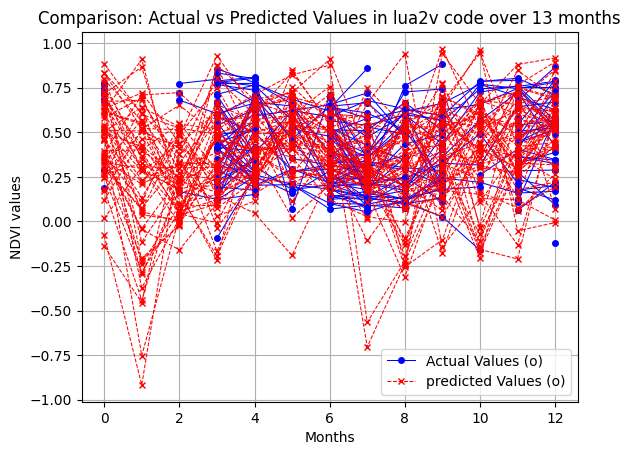

In [113]:
draw_ndvi(lua2_ndvi, nor, "lua2v")

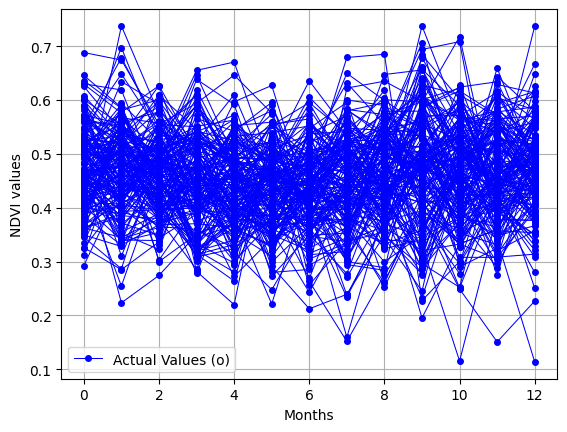

In [14]:

for i, data in enumerate(ndvi_preds):
    plt.plot(months, data, marker='o', linestyle='-', color='blue', markersize=4, linewidth=0.75, label='Actual Values (o)' if i == 0 else "")
plt.xlabel('Months')
plt.ylabel('NDVI values')
# Adding grid
plt.grid(True)
plt.legend(loc='best')

# Display the plot
plt.show()

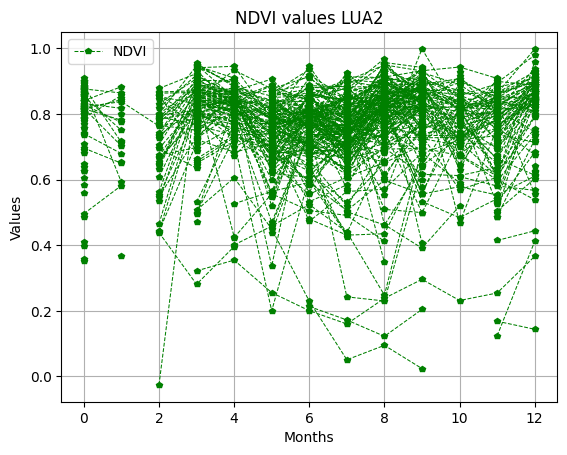

In [15]:
months = np.arange(13)
def draw_vh(vh_values):
    for i, vh in enumerate(vh_values[:]):
        plt.plot(months, vh, marker='p', ls="--", color="g", ms=4, lw=0.75, label='NDVI' if i == 0 else "")
    plt.grid(True)
    plt.legend(loc='best')
    plt.xlabel('Months')
    plt.ylabel('Values')
    plt.title(f'NDVI values LUA2')

draw_vh(lua2_ndvi)

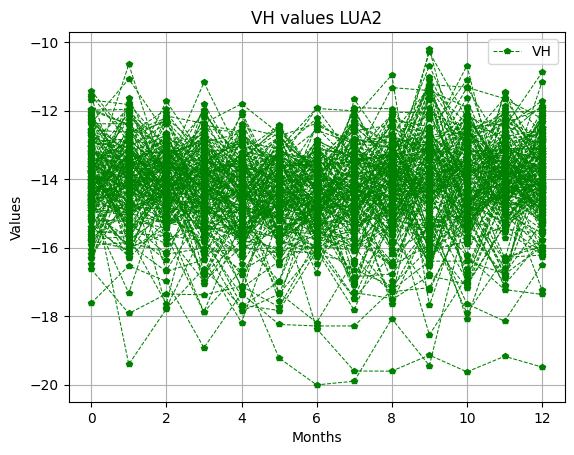

In [16]:
months = np.arange(13)
def draw_vh(vh_values):
    for i, vh in enumerate(vh_values[:]):
        plt.plot(months, vh, marker='p', ls="--", color="g", ms=4, lw=0.75, label='VH' if i == 0 else "")
    plt.grid(True)
    plt.legend(loc='best')
    plt.xlabel('Months')
    plt.ylabel('Values')
    plt.title(f'VH values LUA2')

draw_vh(lua2_vh)

In [ ]:
import numpy as np
import xarray as xr

ndvi_band = ndvi[5]
vh_band = vh[5]

# Tạo bản sao để không ghi đè dữ liệu gốc
ndvi_filled = ndvi_band.copy()

# Tìm vị trí bị NaN
mask_nan = np.isnan(ndvi_band)

# Gán giá trị mới vào chỗ NaN dựa trên VH
ndvi_filled.values[mask_nan.values] = estimate_ndvi_from_vh(vh_band.values[mask_nan.values])
